In [1]:
import tensorflow as tf
import keras_tuner as kt

from hyperparameter_search import CustomHyperModel
from load_data import load_datasets
%matplotlib inline
#from helper_functions import eval_model

# we want to use mixed precision so
tf.keras.mixed_precision.set_global_policy(tf.keras.mixed_precision.Policy('mixed_float16'))

2024-04-01 11:28:10.383931: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-01 11:28:10.383989: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-01 11:28:10.385645: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-01 11:28:10.392375: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3090, compute capability 8.6


2024-04-01 11:28:13.113289: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-01 11:28:13.127082: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-01 11:28:13.127117: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-01 11:28:13.127849: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
# first set some initial data up
dataset_path='130kv2/'
class_map = {0:"Original", 1:"Poisoned"}

# expected image resolution (all samples should have equal width/height), if set to a lower value samples will be resized accordingly
image_size=512
# batch size to use
batch_size=32

2024-04-01 11:28:13.149783: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-01 11:28:13.149851: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-01 11:28:13.149878: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-01 11:28:13.311671: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-01 11:28:13.311708: I external/local_xla/xla/stream_executor

Generating preview for dataset 'train' located in '130kv2/'.


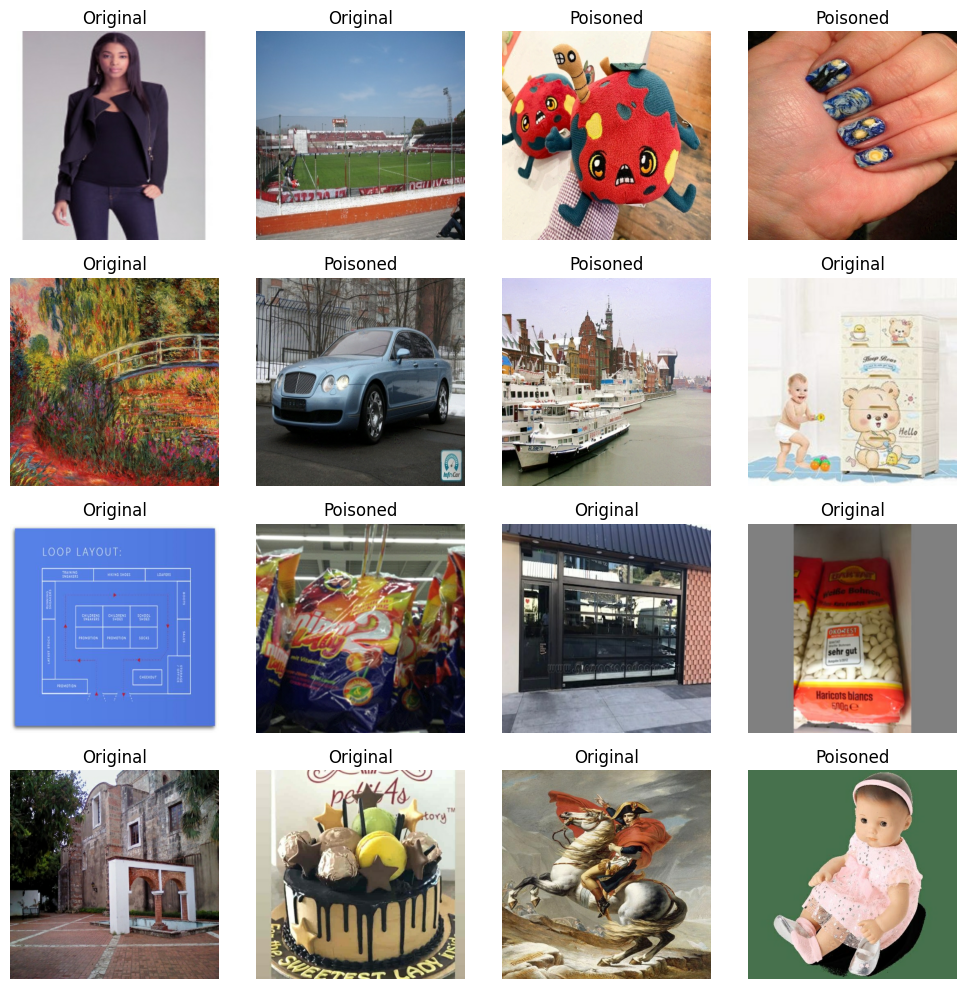

In [3]:
# load our training, validation and test datasets
ds = load_datasets(dataset_path, class_map, image_size, batch_size, preview=True)

In [4]:
# lets try a hyperparameter search on the dataset without resizing first
tuner = kt.BayesianOptimization(
    hypermodel=CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
    objective='val_accuracy',
    max_trials=50,
    num_initial_points=None, # might want to play with this as our model has somewhat excessive dimensionality
    alpha=1e-2,
    beta=3.2,
    seed=321,
    max_retries_per_trial=1, # we'll retry once but these are probably memory errors
    max_consecutive_failed_trials=3,
    directory='autotune',
    project_name='bayesopt_size512_batch32'
)

# tuner.search_space_summary()

# set up the callback for early stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
]

# and then begin the search
tuner.search(
    ds['train'],
    epochs=10,
    callbacks=[callbacks],
    validation_data=ds['validation'],
)


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
2.5e-05           |2.5e-05           |learning_rate
True              |True              |aug_norm
True              |True              |aug_flip
0.15              |0.15              |aug_rotate
128               |128               |conv1_size
False             |False             |residual_connections
3                 |3                 |midblock_repetitions
384               |384               |midblock_1_size
768               |768               |midblock_2_size
768               |768               |midblock_3_size
1280              |1280              |final_conv_size
0.1               |0.1               |dropout

Epoch 1/10


2024-04-01 11:28:23.413156: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:467] Loaded cuDNN version 90000


In [ ]:
# now we can fetch and save the best hps
# we'll get the top 5 so we can review and look for any commonalities/eliminate outliers
best_hps=tuner.get_best_hyperparameters(num_trials=5)
# model = tuner.hypermodel.build(best_hps)

In [ ]:
# now lets repeat this, but redo the datasets at 256x256 and a batch size of 32
image_size=256
batch_size=32

# reload our training, validation and test datasets
ds = load_datasets(dataset_path, class_map, image_size, batch_size)

tuner = kt.BayesianOptimization(
    hypermodel=CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
    objective='val_accuracy',
    max_trials=50,
    num_initial_points=None, # might want to play with this as our model has somewhat excessive dimensionality
    alpha=1e-2,
    beta=3.2,
    seed=321,
    hyperparameters=None,
    max_retries_per_trial=1, # we'll retry once but these are probably memory errors
    max_consecutive_failed_trials=3,
    directory='autotune',
    project_name='bayesopt_crop256_batch32'
)

# tuner.search_space_summary()

# set up the callback for early stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
]

# and then begin the search
tuner.search(
    ds['train'],
    epochs=10,
    callbacks=[callbacks],
    validation_data=ds['validation'],
)

# lastly save the best hps, we'll get the top 5 so we can review and look for any commonalities/eliminate outliers
best_hps=tuner.get_best_hyperparameters(num_trials=5)
# model = tuner.hypermodel.build(best_hps)

In [ ]:
"""
# see https://www.tensorflow.org/tutorials/keras/keras_tuner
tuner = kt.Hyperband(
    CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='autotune',
    project_name='hyperband'
)
"""

In [ ]:
"""
epochs = 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("models/save_at_{epoch}.keras"),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
]
model_history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
).history
"""

In [ ]:
"""
#model = tf.keras.models.load_model('save_at_3.keras')
eval_results = eval_model('initial_model',model,model_history,val_ds,test_ds)
#model_history
"""